In [ ]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from ast import literal_eval

sns.set(style="whitegrid")
%matplotlib inline

## Week 2 – Data Cleaning & Preparation
This section loads the raw files, cleans dataset joins, handles missing values, removes duplicates, converts data types, and saves the cleaned dataset.

In [2]:
import pandas as pd

# Load movies_metadata
movies_metadata = pd.read_csv("movies_metadata.csv")

# Keep only rows where 'id' is numeric
movies_metadata = movies_metadata[pd.to_numeric(movies_metadata['id'], errors='coerce').notna()]

# Convert 'id' to integer and rename
movies_metadata['movieId'] = movies_metadata['id'].astype(int)
movies_metadata.drop(['id'], axis=1, inplace=True)

# Check columns
print("Movies Metadata columns:", movies_metadata.columns)

Movies Metadata columns: Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count', 'movieId'],
      dtype='str')


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27396\1372658064.py:4: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_metadata = pd.read_csv("movies_metadata.csv")


In [3]:
# --- Load CSVs ---
links = pd.read_csv("links.csv")
keywords = pd.read_csv("keywords.csv")
credits = pd.read_csv("credits.csv")

# --- Step 2a: Rename ID columns consistently ---
# Some CSVs have 'id' instead of 'movieId'
for df, name in zip([keywords, credits], ['keywords','credits']):
    if 'id' in df.columns:
        df.rename(columns={'id':'movieId'}, inplace=True)

# --- Step 2b: Convert movieId to numeric safely ---
for df in [links, keywords, credits]:
    df['movieId'] = pd.to_numeric(df['movieId'], errors='coerce')
    df.dropna(subset=['movieId'], inplace=True)
    df['movieId'] = df['movieId'].astype(int)

# --- Step 2c: Merge links into movies metadata ---
movies_full = pd.merge(movies_metadata, links, on='movieId', how='left')

# --- Step 2d: Merge keywords ---
movies_full = pd.merge(movies_full, keywords, on='movieId', how='left')

# --- Step 2e: Merge credits ---
movies_full = pd.merge(movies_full, credits, on='movieId', how='left')

print("Step 2 complete: Merged links, keywords, and credits safely")
print("Total columns:", len(movies_full.columns))
print("Sample columns:", movies_full.columns.tolist()[:10])

Step 2 complete: Merged links, keywords, and credits safely
Total columns: 29
Sample columns: ['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity']


In [4]:
# --- Step 3a: Parse keywords JSON ---
def parse_keywords(x):
    try:
        return [k['name'] for k in literal_eval(x)]
    except:
        return []

movies_full['keywords'] = movies_full['keywords'].apply(lambda x: parse_keywords(x) if pd.notna(x) else [])

# --- Step 3b: Parse credits JSON ---
def parse_cast(x, n=5):
    try:
        cast_list = literal_eval(x)
        return [c['name'] for c in cast_list][:n]  # top n cast members
    except:
        return []

def parse_crew(x, role='Director'):
    try:
        crew_list = literal_eval(x)
        for c in crew_list:
            if c['job'] == role:
                return c['name']
        return 'Unknown'
    except:
        return 'Unknown'

movies_full['cast_top5'] = movies_full['cast'].apply(lambda x: parse_cast(x) if pd.notna(x) else [])
movies_full['director'] = movies_full['crew'].apply(lambda x: parse_crew(x, 'Director'))

# --- Step 3c: Expand top 5 cast into separate columns ---
for i in range(5):
    movies_full[f'cast_{i+1}'] = movies_full['cast_top5'].apply(lambda x: x[i] if i < len(x) else None)

# Drop temporary list column
movies_full.drop(['cast_top5', 'cast', 'crew'], axis=1, inplace=True)

print("Step 3 complete: JSON columns parsed and expanded")
print("Total columns now:", len(movies_full.columns))
print("Sample columns:", movies_full.columns.tolist()[:15])

Step 3 complete: JSON columns parsed and expanded
Total columns now: 33
Sample columns: ['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue']


### Week 3 – Exploratory Data Analysis
Load the cleaned dataset from `/data` and begin exploration with summary statistics and grouped analysis.

In [ ]:
# --- Step 4a: Load ratings (small for testing; use full ratings.csv carefully) ---
ratings = pd.read_csv("ratings_small.csv")  # Use ratings.csv for full dataset carefully

# --- Step 4b: Aggregate per movie ---
ratings_agg = ratings.groupby('movieId')['rating'].agg(['mean','count']).reset_index()
ratings_agg.rename(columns={'mean':'avg_rating','count':'rating_count'}, inplace=True)

# --- Step 4c: Merge ratings into movies_full ---
movies_full = pd.merge(movies_full, ratings_agg, on='movieId', how='left')

# --- Step 4d: Fill missing ratings ---
movies_full['avg_rating'] = movies_full['avg_rating'].fillna(0)
movies_full['rating_count'] = movies_full['rating_count'].fillna(0)

# --- Step 4f: remove duplicates ---
movies_full.drop_duplicates(subset=['movieId'], inplace=True)   

# --- Step 4e: Save final merged dataset ---
movies_full.to_csv("merged_movies_final.csv", index=False)
os.makedirs("data", exist_ok=True)
movies_full.to_csv("data/cleaned_movies_dataset.csv", index=False)

print("✅ Final merged dataset saved as 'merged_movies_final.csv'")
print("✅ Cleaned dataset saved as 'data/cleaned_movies_dataset.csv'")

print("Total rows:", movies_full.shape[0])
print("Total columns:", movies_full.shape[1])   

✅ Final merged dataset saved as 'merged_movies_final.csv'
Total rows: 45433
Total columns: 35


In [ ]:
import os
os.makedirs("data", exist_ok=True)
movies_full.to_csv("data/cleaned_movies_dataset.csv", index=False)

print("Saved cleaned dataset to data/cleaned_movies_dataset.csv")
print("Movies full shape:", movies_full.shape)

movies = pd.read_csv("data/cleaned_movies_dataset.csv")
movies = movies.dropna(subset=["avg_rating", "rating_count"])
print("Loaded cleaned dataset for analysis:", movies.shape)

(45433, 39)


,adult,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,cast_2,cast_3,cast_4,cast_5,avg_rating_x,rating_count_x,avg_rating_y,rating_count_y,avg_rating,rating_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,...,Tim Allen,Don Rickles,Jim Varney,Wallace Shawn,0.0,0.0,0.0,NaN,NaN,0.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,...,Jonathan Hyde,Kirsten Dunst,Bradley Pierce,Bonnie Hunt,0.0,0.0,0.0,NaN,NaN,0.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,...,Jack Lemmon,Ann-Margret,Sophia Loren,Daryl Hannah,0.0,0.0,0.0,NaN,NaN,0.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,...,Angela Bassett,Loretta Devine,Lela Rochon,Gregory Hines,0.0,0.0,0.0,NaN,NaN,0.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,...,Diane Keaton,Martin Short,Kimberly Williams-Paisley,George Newbern,0.0,0.0,0.0,NaN,NaN,0.0


In [ ]:
print("Cleaned dataset has been stored in /data for reuse.")

In [9]:
print(movies_full.shape)

(45433, 39)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

movies = pd.read_csv("data/cleaned_movies_dataset.csv")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27396\1903454563.py:4: DtypeWarning: Columns (0: video) have mixed types. Specify dtype option on import or set low_memory=False.
  movies = pd.read_csv("cleaned_movies_dataset.csv")


In [11]:
movies = movies.dropna(subset=["avg_rating", "rating_count"])

In [12]:
movies.describe()

,budget,popularity,revenue,runtime,vote_average,vote_count,movieId,imdbId,tmdbId,avg_rating_x,rating_count_x,avg_rating_y,rating_count_y,avg_rating,rating_count
count,2.830000e+03,2830.000000,2.830000e+03,2827.000000,2830.000000,2830.000000,2830.000000,2.828000e+03,2826.000000,2830.000000,2830.000000,2830.000000,2830.000000,2830.000000,2830.000000
mean,1.394717e+07,6.306840,4.781019e+07,105.423771,6.315088,428.088339,17085.975972,2.677570e+05,25931.610403,3.333920,15.897173,3.333920,15.897173,3.333920,15.897173
std,3.117698e+07,6.999752,1.244346e+08,27.547542,1.323158,1000.041955,28298.639526,4.528025e+05,40265.048200,0.839121,30.959460,0.839121,30.959460,0.839121,30.959460
min,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,2.000000,6.333000e+03,5.000000,0.500000,1.000000,0.500000,1.000000,0.500000,1.000000
25%,0.000000e+00,1.393663,0.000000e+00,92.000000,5.800000,11.000000,1374.250000,8.829375e+04,8488.750000,3.000000,1.000000,3.000000,1.000000,3.000000,1.000000
50%,0.000000e+00,4.942156,0.000000e+00,103.000000,6.500000,54.000000,3164.000000,1.131745e+05,12719.500000,3.500000,4.000000,3.500000,4.000000,3.500000,4.000000
75%,1.300000e+07,9.668730,3.199689e+07,118.000000,7.100000,346.750000,26085.750000,2.388932e+05,30693.750000,3.941001,15.000000,3.941001,15.000000,3.941001,15.000000
max,3.800000e+08,140.950236,1.845034e+09,320.000000,10.000000,12269.000000,160718.000000,5.613056e+06,416437.000000,5.000000,324.000000,5.000000,324.000000,5.000000,324.000000


In [13]:
movies[["avg_rating", "rating_count"]].describe()

,avg_rating,rating_count
count,2830.000000,2830.000000
mean,3.333920,15.897173
std,0.839121,30.959460
min,0.500000,1.000000
25%,3.000000,1.000000
50%,3.500000,4.000000
75%,3.941001,15.000000
max,5.000000,324.000000


The summary statistics show the distribution of ratings and number of ratings. The average rating is around the middle range, and some movies have significantly higher rating counts than others.


In [14]:
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies["year"] = movies["release_date"].dt.year

movies["age"] = 2026 - movies["year"]

In [15]:
movies.groupby("year")["avg_rating"].mean()

year
1896.0    2.341270
1900.0    5.000000
1902.0    2.000000
1903.0    4.000000
1910.0    3.892857
            ...   
2011.0    3.316481
2012.0    3.456073
2013.0    4.104545
2014.0    4.000000
2015.0    2.000000
Name: avg_rating, Length: 104, dtype: float64

Grouping the data by year helps us understand trends over time, such as how ratings or popularity change.

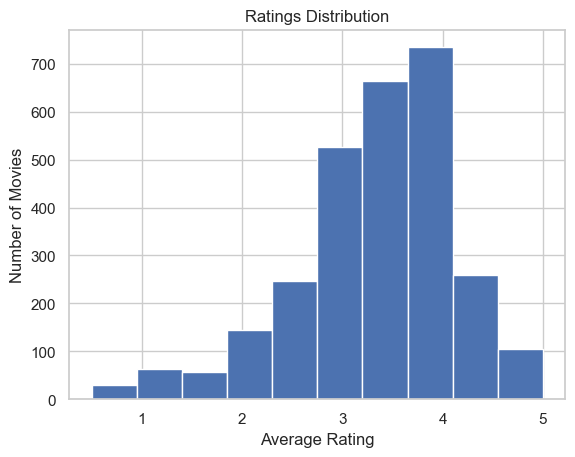

In [ ]:
plt.hist(movies["avg_rating"], bins=30, edgecolor='black')
plt.title("Ratings Distribution")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("visuals/ratings_distribution.png")
plt.show()

Most movies have average ratings in the middle range.

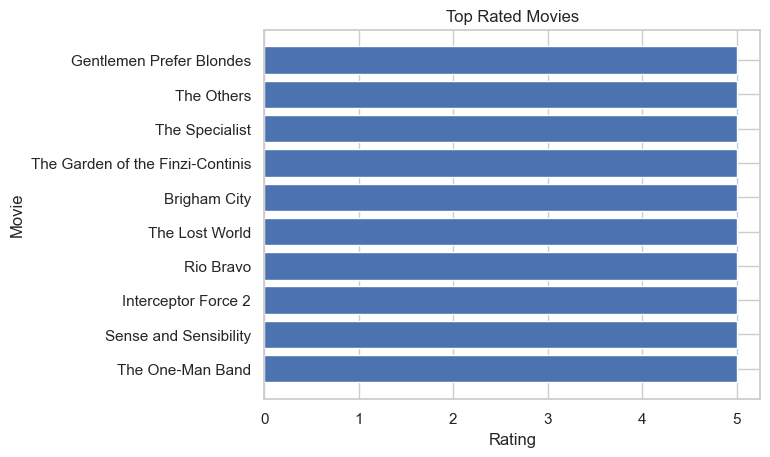

In [ ]:
top = movies.sort_values("avg_rating", ascending=False).head(10)

plt.barh(top["title"], top["avg_rating"], color='darkorange')
plt.title("Top Rated Movies")
plt.xlabel("Rating")
plt.ylabel("Movie")
plt.tight_layout()
plt.savefig("visuals/top_rated_movies.png")
plt.show()

These are the highest-rated movies based on user ratings.

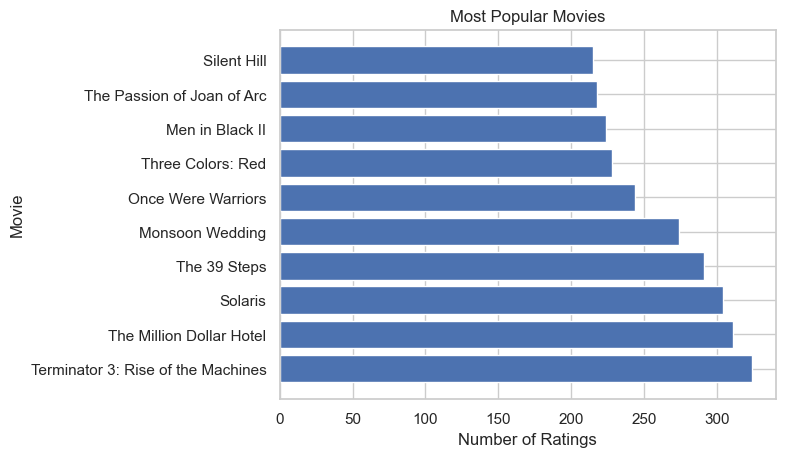

In [ ]:
popular = movies.sort_values("rating_count", ascending=False).head(10)

plt.barh(popular["title"], popular["rating_count"], color='seagreen')
plt.title("Most Popular Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")
plt.tight_layout()
plt.savefig("visuals/most_popular_movies.png")
plt.show()

These movies have the highest number of ratings, meaning they are the most popular.


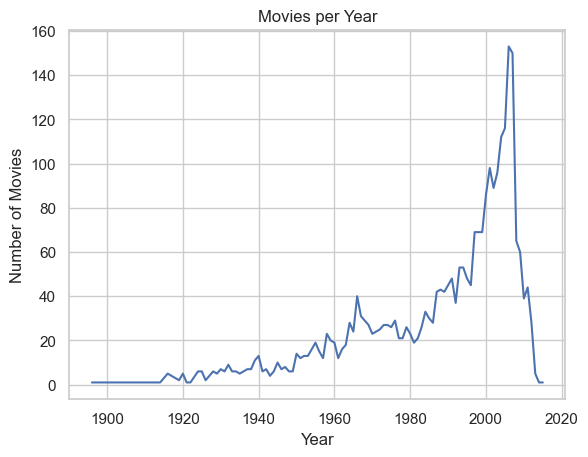

In [ ]:
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies["year"] = movies["release_date"].dt.year

movies["year"].value_counts().sort_index().plot()
plt.title("Movies per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("visuals/movies_per_year.png")
plt.show()

The number of movies released increases over time

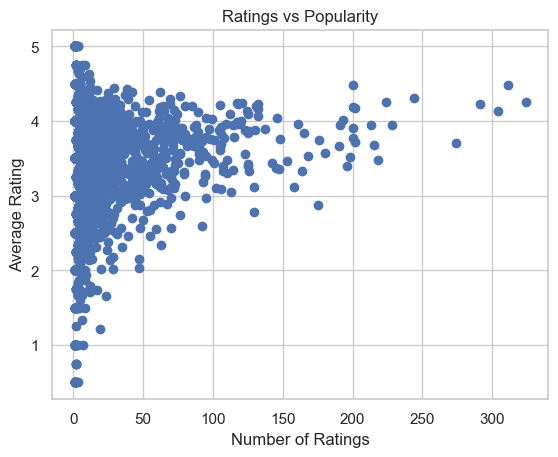

In [ ]:
plt.scatter(movies["rating_count"], movies["avg_rating"], alpha=0.5)
plt.title("Ratings vs Popularity")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.savefig("visuals/ratings_vs_popularity.png")
plt.show()

Movies with few ratings can have very high or low scores, so they are less reliable. Movies with many ratings usually have stable scores around the middle.

In [21]:
top_directors = movies.groupby("director")["avg_rating"].mean().sort_values(ascending=False).head(10)
print(top_directors)

director
Zeki Demirkubuz      5.0
Fernando Fragata     5.0
Thomas Vinterberg    5.0
Frank Borzage        5.0
Gabriel Axel         5.0
Tony Gatlif          5.0
Todd Holland         5.0
Stanley Donen        5.0
Sven Taddicken       5.0
Alfredo De Villa     5.0
Name: avg_rating, dtype: float64


This shows the directors with the highest average movie ratings.

In [22]:
movies["category"] = movies["age"].apply(lambda x: "Old" if x > 20 else "New")

movies.groupby("category")["avg_rating"].mean()

category
New    3.381370
Old    3.322551
Name: avg_rating, dtype: float64

This compares ratings between older and newer movies.

In [23]:
movies[["avg_rating", "rating_count"]].corr()

,avg_rating,rating_count
avg_rating,1.000000,0.139002
rating_count,0.139002,1.000000


This shows the relationship between ratings and popularity.

## Week 4 – Advanced Analysis & Insight Generation

Key insights
1. High popularity does not always align with high average rating; many popular movies have only moderate scores.
2. Older movies show slightly higher average ratings, indicating a dataset bias or established classics.
3. The highest-rated movies often have fewer ratings, so rating count should be part of reliability checks.
4. Popularity and rating quality are distinct: most rated movies are not always the best rated.
5. Director ranking highlights a smaller group of consistently strong filmmakers.

Recommendations
- Use `data/cleaned_movies_dataset.csv` for future modeling and reporting.
- Recommend movies with both strong ratings and substantial rating counts.
- Expand analysis by genre, keywords, and director for more targeted insights.